In [20]:
# Suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Ensure backend is set to 'Agg'
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is imported
%matplotlib inline

import seaborn as sns
# For predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set seaborn style for better aesthetics
sns.set(style='whitegrid')

Import Necessary Libraries

In [22]:
# Load the first data file which contains the Timestamp column
df1 = pd.read_csv('/content/drive/MyDrive/PROJET DS/Student Stress Factors (2).csv',
                  delimiter=',',
                  encoding='MacRoman')

# Load the second data file which does not have the Timestamp column
df2 = pd.read_csv('/content/drive/MyDrive/PROJET DS/Student Stress Factors (2).csv',
                  delimiter=',',
                  encoding='MacRoman')
# Display the first few rows of each (actual display will happen when the notebook is run)
print('df1 columns:', df1.columns.tolist())
print('df2 columns:', df2.columns.tolist())


df1 columns: ['Kindly Rate your Sleep Quality \uf8ffüò¥', 'How many times a week do you suffer headaches \uf8ffü§ï?', 'How would you rate you academic performance \uf8ffüë©‚Äç\uf8ffüéì?', 'how would you rate your study load?', 'How many times a week you practice extracurricular activities \uf8ffüéæ?', 'How would you rate your stress levels?']
df2 columns: ['Kindly Rate your Sleep Quality \uf8ffüò¥', 'How many times a week do you suffer headaches \uf8ffü§ï?', 'How would you rate you academic performance \uf8ffüë©‚Äç\uf8ffüéì?', 'how would you rate your study load?', 'How many times a week you practice extracurricular activities \uf8ffüéæ?', 'How would you rate your stress levels?']


## **Data Cleaning and Preprocessing**

In [23]:
# Strip any accidental whitespace from column names in both dataframes
df1.columns = [col.strip() for col in df1.columns]
df2.columns = [col.strip() for col in df2.columns]

# For df1, the 'Timestamp' column is supposed to represent dates. Let's attempt to convert it.
if 'Timestamp' in df1.columns:
    try:
        df1['Timestamp'] = pd.to_datetime(df1['Timestamp'])
    except Exception as e:
        print('Error converting Timestamp column:', e)
        # This method is important in many notebooks since improper date parsing can affect temporal analyses.
# A peek into the cleaned columns
print('Cleaned df1 columns:', df1.columns.tolist())
print('Cleaned df2 columns:', df2.columns.tolist())

Cleaned df1 columns: ['Kindly Rate your Sleep Quality \uf8ffüò¥', 'How many times a week do you suffer headaches \uf8ffü§ï?', 'How would you rate you academic performance \uf8ffüë©‚Äç\uf8ffüéì?', 'how would you rate your study load?', 'How many times a week you practice extracurricular activities \uf8ffüéæ?', 'How would you rate your stress levels?']
Cleaned df2 columns: ['Kindly Rate your Sleep Quality \uf8ffüò¥', 'How many times a week do you suffer headaches \uf8ffü§ï?', 'How would you rate you academic performance \uf8ffüë©‚Äç\uf8ffüéì?', 'how would you rate your study load?', 'How many times a week you practice extracurricular activities \uf8ffüéæ?', 'How would you rate your stress levels?']


# Exploratory Data **Analysis** **texte en gras**

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                                                               Non-Null Count  Dtype
---  ------                                                               --------------  -----
 0   Kindly Rate your Sleep Quality üò¥                                  520 non-null    int64
 1   How many times a week do you suffer headaches ü§ï?                  520 non-null    int64
 2   How would you rate you academic performance üë©‚Äçüéì?             520 non-null    int64
 3   how would you rate your study load?                                  520 non-null    int64
 4   How many times a week you practice extracurricular activities üéæ?  520 non-null    int64
 5   How would you rate your stress levels?                               520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB
Summary Statistics:
       Kindly Rate your Sleep Quality üò¥  \
count  

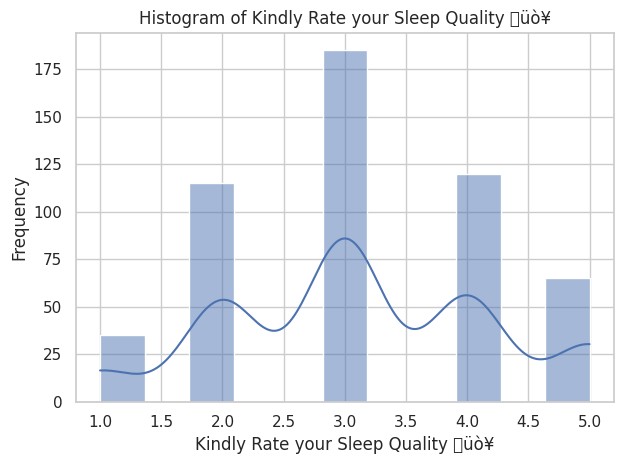

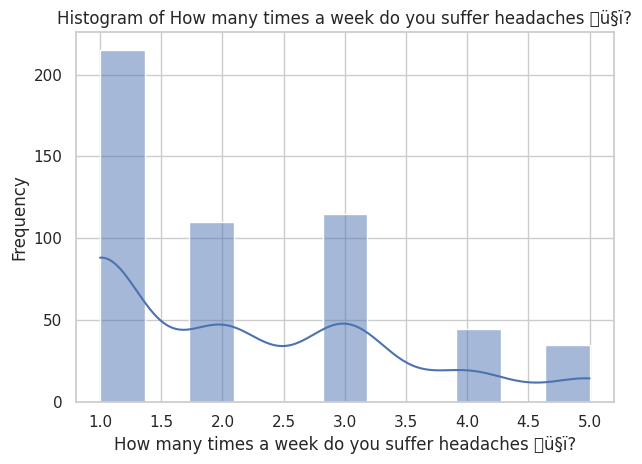

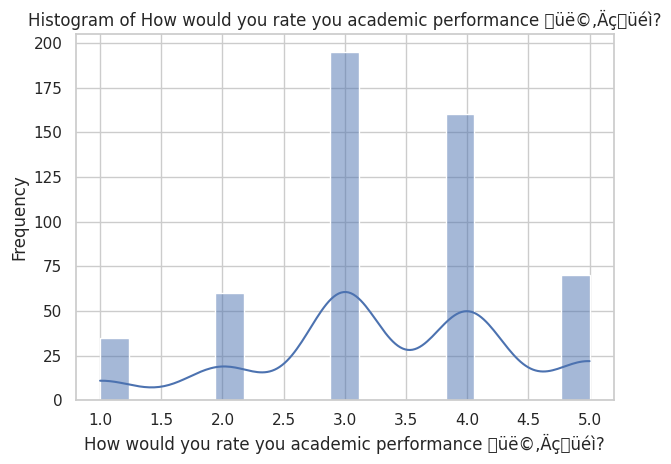

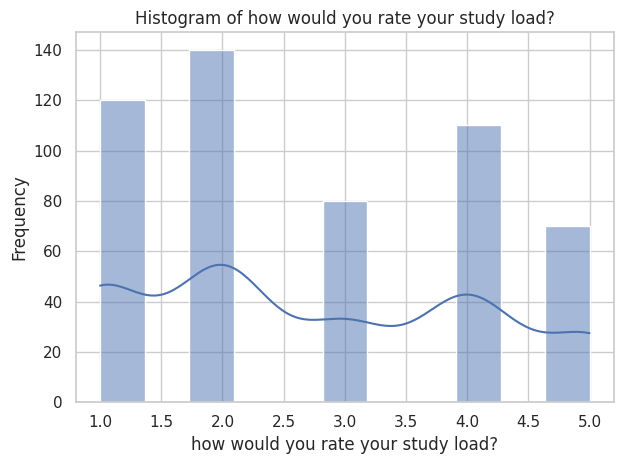

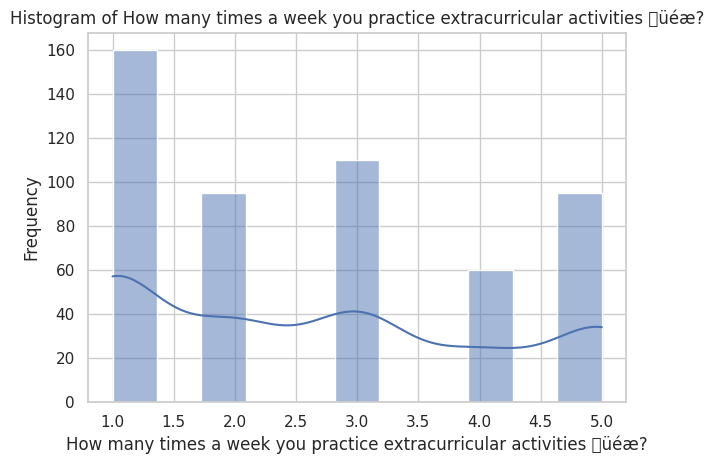

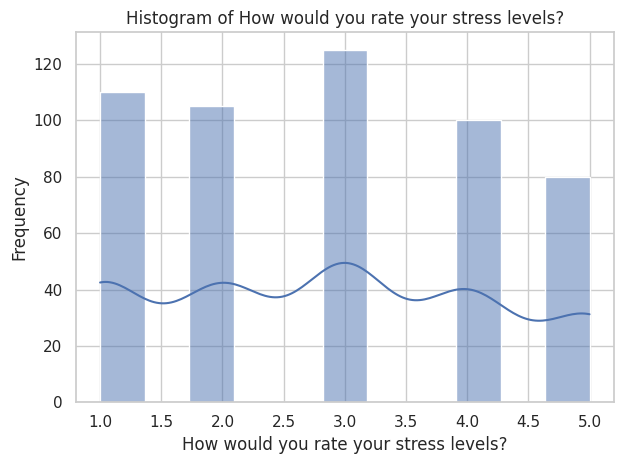

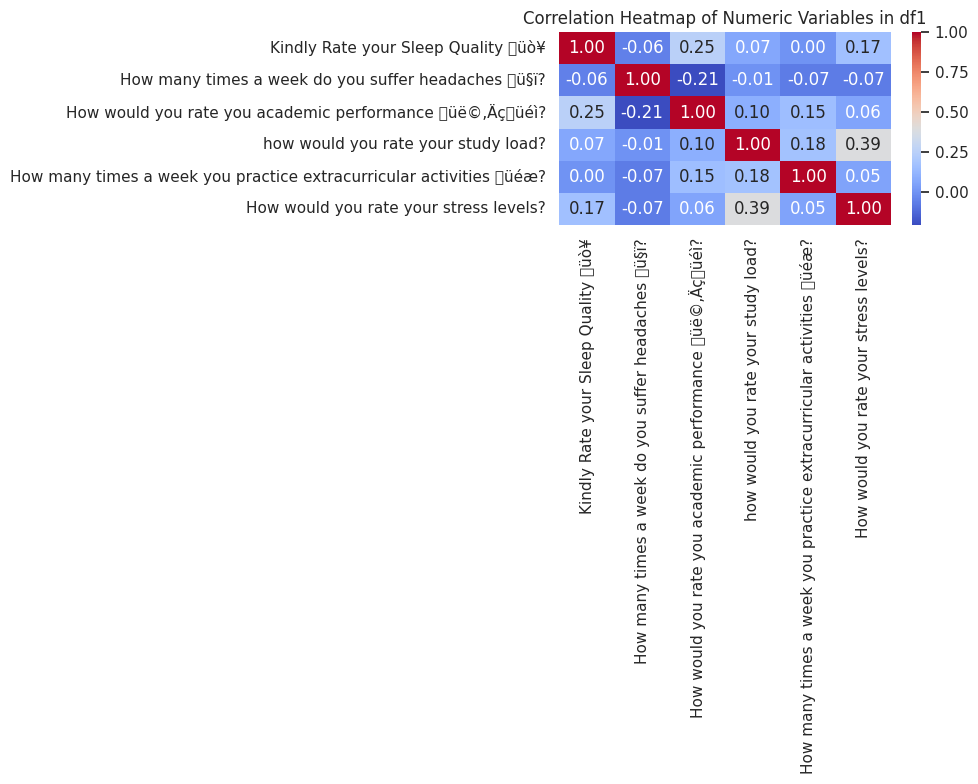

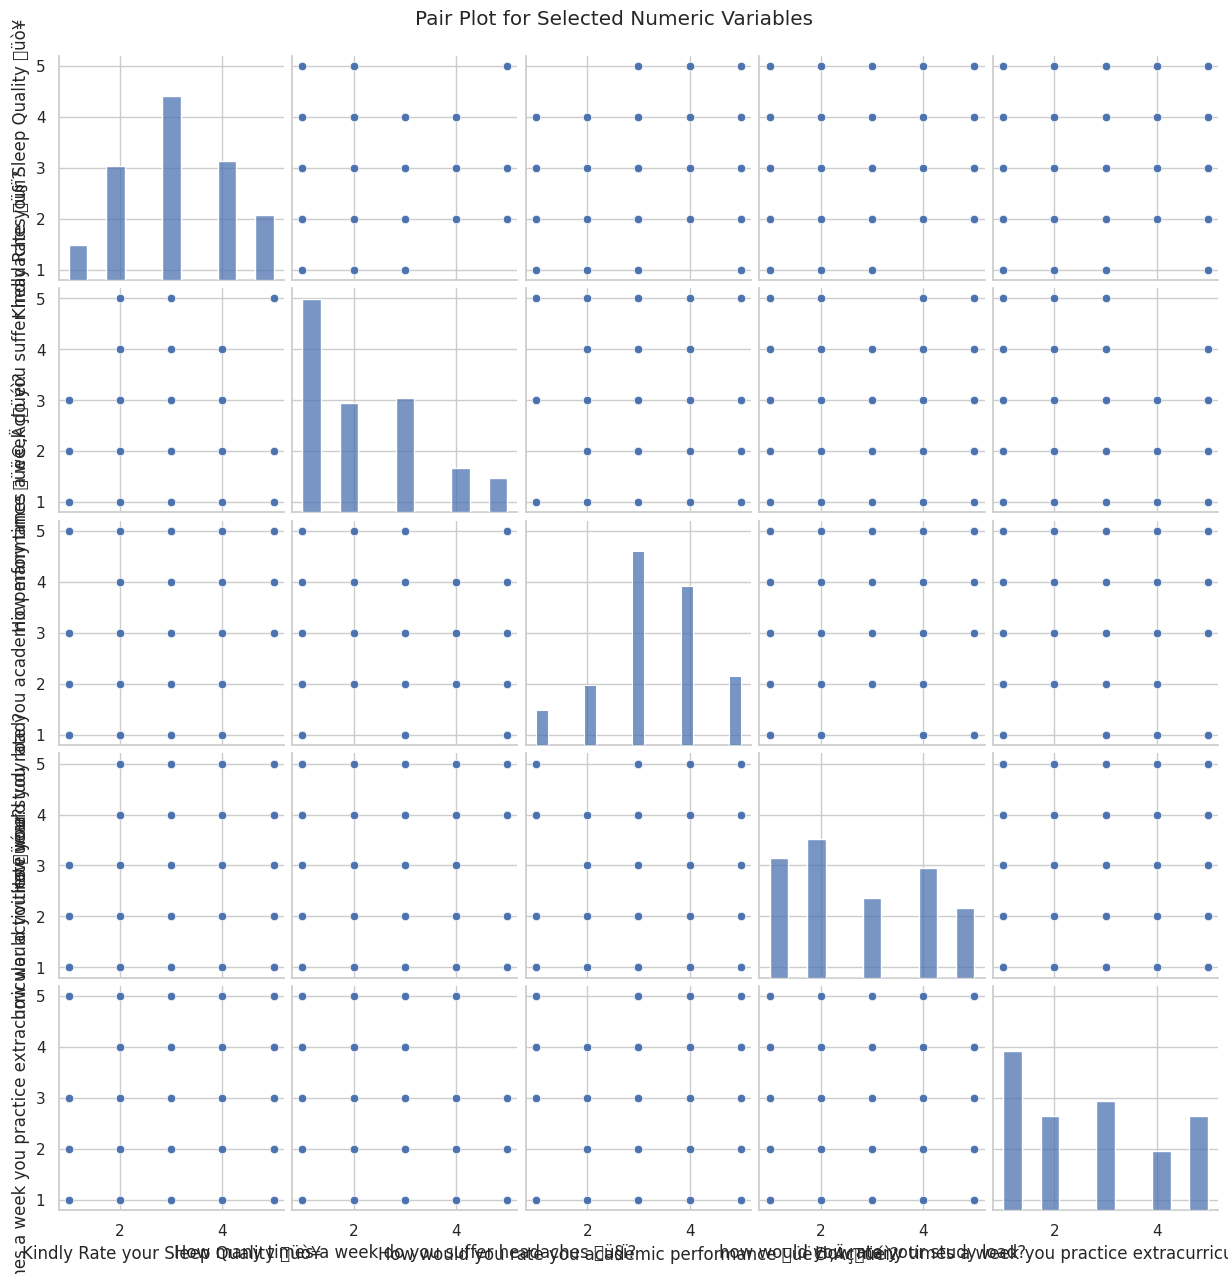

In [24]:
# Let's perform EDA on the first dataframe (df1)

print('DataFrame Info:')
df1.info()

# Check summary statistics
print('Summary Statistics:')
print(df1.describe())

# Plot histograms for the numeric columns
numeric_cols_df1 = df1.select_dtypes(include=[np.number]).columns
for col in numeric_cols_df1:
    plt.figure()
    sns.histplot(df1[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# If there are four or more numeric columns, create a correlation heatmap
if len(numeric_cols_df1) >= 4:
    numeric_df1 = df1[numeric_cols_df1]
    plt.figure(figsize=(10, 8))
    corr = numeric_df1.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Variables in df1')
    plt.tight_layout()
    plt.show()
# Create a pair plot for a subset of columns due to potential visual clutter
cols_for_pairplot = numeric_cols_df1 if len(numeric_cols_df1) <= 5 else numeric_cols_df1[:5]
sns.pairplot(df1[cols_for_pairplot])
plt.suptitle('Pair Plot for Selected Numeric Variables', y=1.02)
plt.show()

# **Merging Data for Predictive Modeling**

In [25]:
# For predictive modeling, we want to predict 'How would you rate your stress levels?'
# Both datasets share the same features (apart from the Timestamp column in df1). We remove the Timestamp column before merging.

if 'Timestamp' in df1.columns:
    df1_model = df1.drop(columns=['Timestamp']).copy()
else:
    df1_model = df1.copy()

# Align the columns in df2 with df1_model if necessary
df2_model = df2.copy()

# Concatenate the two dataframes vertically
df_all = pd.concat([df1_model, df2_model], ignore_index=True)
# Display merged dataframe shape
print('Combined dataframe shape:', df_all.shape)

Combined dataframe shape: (1040, 6)


# **Predictive Modeling**

In [26]:
# Our target variable is assumed to be 'How would you rate your stress levels?'
# The other survey questions will be used as features.

# Define the feature and target columns
target_col = 'How would you rate your stress levels?'
feature_cols = [col for col in df_all.columns if col != target_col]

# Check if target column exists
if target_col not in df_all.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe")

# For modeling, we consider only numeric columns. In our case all feature columns are expected to be integers.
X = df_all[feature_cols].select_dtypes(include=[np.number])
y = df_all[target_col]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Create and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
# Calculate the R-squared score as the prediction accuracy metric
r2 = r2_score(y_test, y_pred)
print(f"R-squared Score of the predictor: {r2:.4f}")


R-squared Score of the predictor: 0.1554


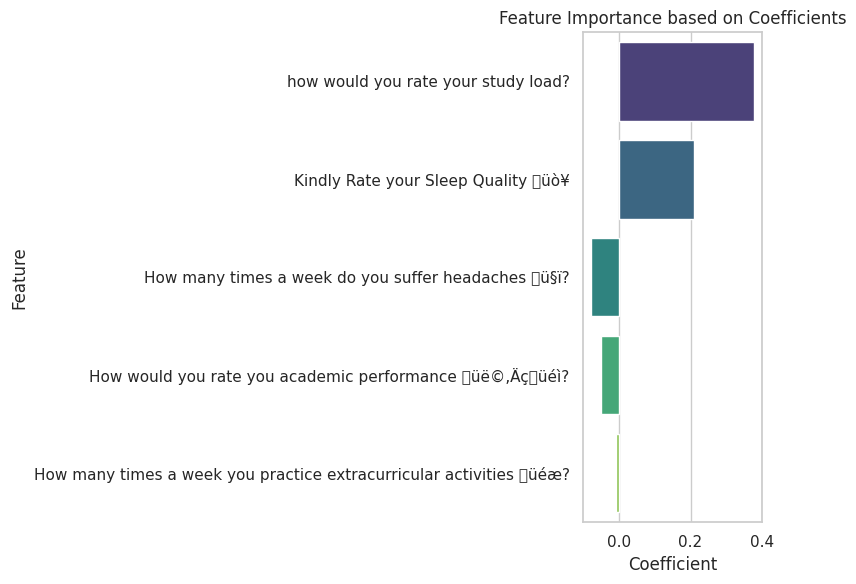

In [27]:
# For linear regression, the coefficients can indicate the feature importance
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Importance based on Coefficients')
plt.tight_layout()
plt.show()

ConclusionIn this notebook, we have walked through the process of loading and cleaning survey data about student stress factors, performed exploratory analyses using various visualization techniques, and built a linear regression model to predict stress levels from features such as sleep quality, study load, and extracurricular participation. The model provides an R-squared score, giving a preliminary understanding of how well the features can predict stress levels.Future analysis may involve using more complex models, exploring non-linear relationships, or even segmenting the data based on additional demographic factors if available. Additionally, techniques like permutation importance could further refine our understanding of feature contributions.If you found this analysis useful, please consider upvoting it.